🚗 MC2 Zone 4 - Cycle Time Analysis (Gigafactory Sparks, NV)
Target Cycle Time: 48 seconds
                    Station  Avg_Cycle_Time  Deviation  Miss_Percent
2      Adhesive Application              71         23          30.3
5     Cooling Plate Install              68         20          26.3
0  Battery Module Placement              62         14          18.4
6         Torque Station 12              59         11          14.5
1              Weld Robot 4              55          7           9.2
4           Quality Check 2              53          5           6.6
3         Busbar Connection              48          0           0.0
7           Final Alignment              44         -4          -5.3


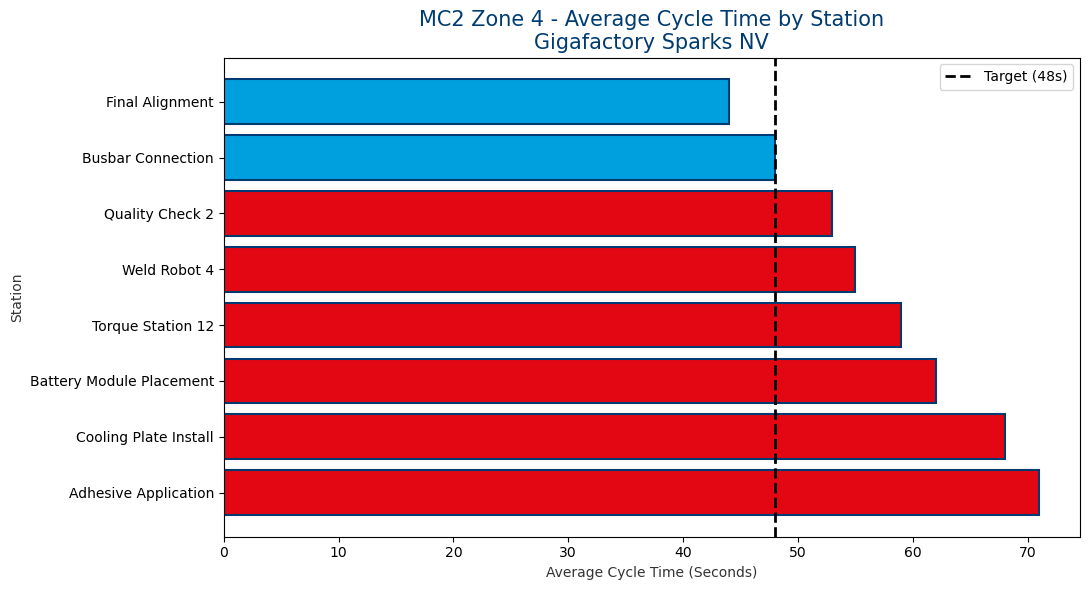

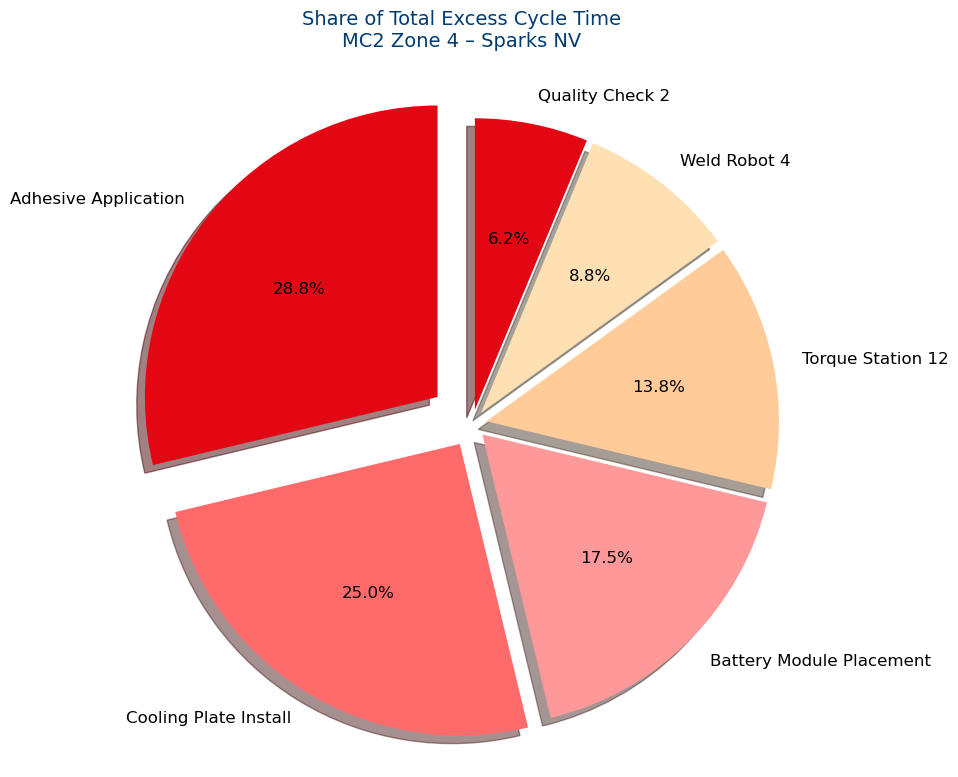

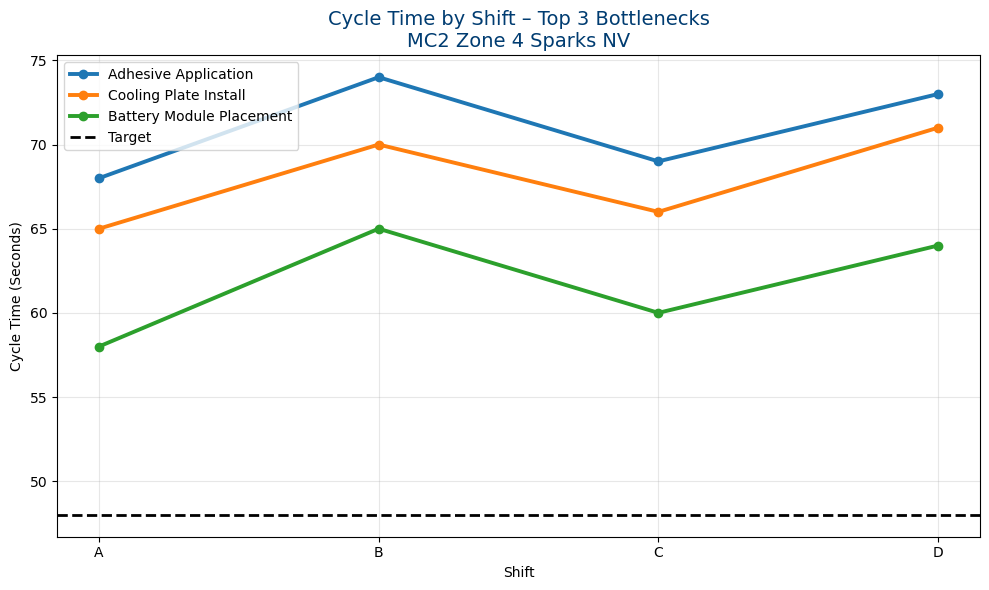


✅ Charts saved to your folder:
 • tesla_mc2_cycle_bar.png
 • tesla_mc2_cycle_pie.png
 • tesla_mc2_cycle_line.png

Adhesive Application and Cooling Plate Install are the biggest issues (miss target on every shift).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Mock real-world data: MC2 Zone 4 - Gigafactory Sparks NV
data = {
'Station': [
'Battery Module Placement', 'Weld Robot 4', 'Adhesive Application',
'Busbar Connection', 'Quality Check 2', 'Cooling Plate Install',
'Torque Station 12', 'Final Alignment'
],
'Avg_Cycle_Time': [62, 55, 71, 48, 53, 68, 59, 44], # overall average
'Target_sec': 48,
'Shift_A': [58, 52, 68, 47, 51, 65, 57, 43],
'Shift_B': [65, 57, 74, 49, 54, 70, 61, 45],
'Shift_C': [60, 54, 69, 46, 52, 66, 58, 42],
'Shift_D': [64, 56, 73, 50, 55, 71, 60, 46]
}

df = pd.DataFrame(data)

# Calculate how often they miss target
df['Deviation'] = df['Avg_Cycle_Time'] - df['Target_sec']
df['Misses_Target'] = df['Deviation'] > 0
df['Miss_Percent'] = (df['Deviation'] / df['Deviation'].sum() * 100).round(1)

# Sort worst to best
df_sorted = df.sort_values('Avg_Cycle_Time', ascending=False)

print("🚗 MC2 Zone 4 - Cycle Time Analysis (Gigafactory Sparks, NV)")
print("Target Cycle Time: 48 seconds")
print(df_sorted[['Station', 'Avg_Cycle_Time', 'Deviation', 'Miss_Percent']])

# Tesla colors
tesla_blue = '#003C71'
tesla_light_blue = '#00A0DF'
tesla_red = '#E30613' # for stations missing target
tesla_gray = '#333333'

# 1. Bar Chart – Worst stations first
plt.figure(figsize=(11, 6))
colors = [tesla_red if miss else tesla_light_blue for miss in df_sorted['Misses_Target']]
plt.barh(df_sorted['Station'], df_sorted['Avg_Cycle_Time'], color=colors, edgecolor=tesla_blue, linewidth=1.5)
plt.axvline(x=48, color='black', linestyle='--', linewidth=2, label='Target (48s)')
plt.title('MC2 Zone 4 - Average Cycle Time by Station\nGigafactory Sparks NV', color=tesla_blue, fontsize=15)
plt.xlabel('Average Cycle Time (Seconds)', color=tesla_gray)
plt.ylabel('Station', color=tesla_gray)
plt.legend()
plt.tight_layout()
plt.savefig('tesla_mc2_cycle_bar.png')
plt.show()

# 2. Pie Chart – Share of Total Excess Cycle Time (only stations that miss target)
missers = df_sorted[df_sorted['Misses_Target']].copy() # or .head(5) if you want top 5 only

n = len(missers)
explode = [0.15 if i == 0 else 0.08 if i == 1 else 0.05 for i in range(n)] # biggest slice explodes most

plt.figure(figsize=(9, 9))
plt.pie(missers['Deviation'],
labels=missers['Station'],
autopct='%1.1f%%',
colors=[tesla_red, '#ff6b6b', '#ff9999', '#ffcc99', '#ffe0b3'][:n], # Tesla red theme, auto-trims
startangle=90,
shadow=True,
explode=explode,
textprops={'fontsize': 12})

plt.title('Share of Total Excess Cycle Time\nMC2 Zone 4 – Sparks NV',
color=tesla_blue, fontsize=14, pad=20)
plt.axis('equal')
plt.savefig('tesla_mc2_cycle_pie.png')
plt.show()

# 3. Line Chart – Trend by shift for the 3 worst stations
top3 = df_sorted.head(3)['Station'].tolist()
plt.figure(figsize=(10, 6))
for station in top3:
    row = df[df['Station'] == station].iloc[0]
    shifts = ['A', 'B', 'C', 'D']
    times = [row['Shift_A'], row['Shift_B'], row['Shift_C'], row['Shift_D']]
    plt.plot(shifts, times, marker='o', linewidth=2.8, label=station)

plt.axhline(y=48, color='black', linestyle='--', linewidth=2, label='Target')
plt.title('Cycle Time by Shift – Top 3 Bottlenecks\nMC2 Zone 4 Sparks NV', color=tesla_blue, fontsize=14)
plt.xlabel('Shift')
plt.ylabel('Cycle Time (Seconds)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tesla_mc2_cycle_line.png')
plt.show()

print("\n✅ Charts saved to your folder:")
print(" • tesla_mc2_cycle_bar.png")
print(" • tesla_mc2_cycle_pie.png")
print(" • tesla_mc2_cycle_line.png")
print("\nAdhesive Application and Cooling Plate Install are the biggest issues (miss target on every shift).")
